# Notebook 01 - Data Understanding and Quality

**Study:** The Mode-of-Engagement Hypothesis - how generative-AI usage patterns
shape student learning outcomes.

This first notebook establishes the empirical foundation for the study. It has
four jobs:

1. **Understand** the raw table - schema, scale, and meaning of every field.
2. **Interrogate** its quality - missingness, duplication, and plausibility of
   values against their defined ranges.
3. **Engineer** the analysis variables the rest of the study depends on, most
   importantly the within-student outcome `GPA_Delta`.
4. **Persist** a single clean analysis table (`data/processed/students_clean.csv`)
   consumed by Notebooks 02-04.

Nothing here is modelled or interpreted causally; the aim is a trustworthy,
well-characterised dataset.

In [1]:
# Standard library
import warnings
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd

# Visualisation
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Project paths (notebooks live in notebooks/, data one level up)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_CSV = ROOT / "data" / "ai_student_impact_dataset (1).csv"
PROC_DIR = ROOT / "data" / "processed"
PROC_CSV = PROC_DIR / "students_clean.csv"
FIG_DIR = ROOT / "reports" / "figures"
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("pandas", pd.__version__, "| numpy", np.__version__)


pandas 3.0.3 | numpy 2.5.1


In [2]:
# ----------------------------------------------------------------------
# Visual system: one colour-vision-safe palette used across every figure.
# Categorical hues are assigned in a fixed order (never cycled); sequential
# encodings use a single-hue blue ramp; diverging encodings use blue<->red
# with a neutral midpoint. Grids are recessive and marks are thin.
# ----------------------------------------------------------------------
PALETTE = {
    "blue":    "#2a78d6", "aqua":   "#1baf7a", "yellow":  "#eda100",
    "green":   "#008300", "violet": "#4a3aa7", "red":     "#e34948",
    "magenta": "#e87ba4", "orange": "#eb6834",
}
CAT = list(PALETTE.values())

INK, INK_SOFT, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
GOOD, WARN, SERIOUS, CRITICAL = "#0ca30c", "#fab219", "#ec835a", "#d03b3b"

# Ordered status colours for Low / Medium / High categories
RISK_COLORS = {"Low": GOOD, "Medium": WARN, "High": CRITICAL}

# Single-hue sequential ramp (magnitude) and blue<->red diverging ramp (polarity)
_SEQ = ["#eaf2fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ_BLUE = LinearSegmentedColormap.from_list("seq_blue", _SEQ)
DIVERGING = LinearSegmentedColormap.from_list(
    "blue_red", ["#184f95", "#6da7ec", "#f0efec", "#e88a89", "#c0332f"]
)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 110, "savefig.dpi": 150,
    "font.size": 11, "font.family": "sans-serif",
    "axes.edgecolor": BASELINE, "axes.linewidth": 1.0,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.labelcolor": INK_SOFT, "axes.labelsize": 10.5,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.frameon": False, "legend.fontsize": 10,
    "lines.linewidth": 2.0, "lines.markersize": 7,
})

def style_axis(ax):
    """Recessive grid on y only; clean baseline."""
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", visible=True)
    for s in ("left",):
        ax.spines[s].set_color(BASELINE)
    return ax

sns.set_style("white")
print("Visual system ready:", len(CAT), "categorical hues.")


Visual system ready: 8 categorical hues.


## 1. Load the raw data

The raw CSV is treated as immutable. We load it once and never write back to it.

In [3]:
df_raw = pd.read_csv(RAW_CSV)
print(f"Rows: {df_raw.shape[0]:,}   Columns: {df_raw.shape[1]}")
df_raw.head()

Rows: 50,000   Columns: 16


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


## 2. Schema and memory footprint

We confirm the dtype of each field and its role (identifier, categorical,
ordinal, numeric, or outcome). This mapping drives every downstream decision.

In [4]:
schema = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "n_unique": df_raw.nunique(),
    "example": [df_raw[c].iloc[0] for c in df_raw.columns],
})
print(f"In-memory size: {df_raw.memory_usage(deep=True).sum()/1e6:.1f} MB")
schema

In-memory size: 21.6 MB


,dtype,n_unique,example
Student_ID,int64,50000,100001
Major_Category,str,5,Humanities
Year_of_Study,str,5,Senior
Pre_Semester_GPA,float64,2389,2.418
Weekly_GenAI_Hours,float64,3566,23.31
Primary_Use_Case,str,5,Copywriting/Drafting
Prompt_Engineering_Skill,str,3,Beginner
Tool_Diversity,int64,5,1
Paid_Subscription,bool,2,True
Traditional_Study_Hours,float64,2516,8.13


## 3. Missingness and duplication

Two integrity questions: is any value absent, and does any student appear twice?
A dataset with hidden missingness or duplicated units would invalidate the
inference in later notebooks.

In [5]:
n_missing = int(df_raw.isnull().sum().sum())
n_dup_rows = int(df_raw.duplicated().sum())
n_dup_ids = int(df_raw["Student_ID"].duplicated().sum())
print(f"Missing cells .............. {n_missing}")
print(f"Fully duplicated rows ...... {n_dup_rows}")
print(f"Duplicated Student_IDs ..... {n_dup_ids}")
assert n_missing == 0, "Unexpected missing values"
assert n_dup_ids == 0, "Student_ID is not unique"
print("\nIntegrity checks passed: complete and one row per student.")

Missing cells .............. 0
Fully duplicated rows ...... 0
Duplicated Student_IDs ..... 0

Integrity checks passed: complete and one row per student.


## 4. Numeric distributions

Summary statistics followed by a small-multiple grid of histograms. We look for
scale, skew, floor/ceiling effects (GPA is bounded at 4.0), and multi-modality.

In [6]:
num_cols = ["Pre_Semester_GPA", "Post_Semester_GPA", "Weekly_GenAI_Hours",
            "Traditional_Study_Hours", "Tool_Diversity", "Perceived_AI_Dependency",
            "Anxiety_Level_During_Exams", "Skill_Retention_Score"]
df_raw[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Pre_Semester_GPA,50000.0,3.15,0.48,1.18,2.83,3.21,3.52,4.00
Post_Semester_GPA,50000.0,3.35,0.50,1.00,3.02,3.42,3.75,4.00
Weekly_GenAI_Hours,50000.0,8.43,8.27,0.00,2.39,5.80,11.72,40.00
Traditional_Study_Hours,50000.0,11.21,5.16,1.00,7.56,11.18,14.71,35.86
Tool_Diversity,50000.0,2.80,1.19,1.00,2.00,3.00,4.00,5.00
Perceived_AI_Dependency,50000.0,3.51,1.82,1.00,2.00,3.00,5.00,10.00
Anxiety_Level_During_Exams,50000.0,4.27,2.14,1.00,3.00,4.00,6.00,10.00
Skill_Retention_Score,50000.0,75.80,13.28,10.78,66.82,76.00,85.19,100.00


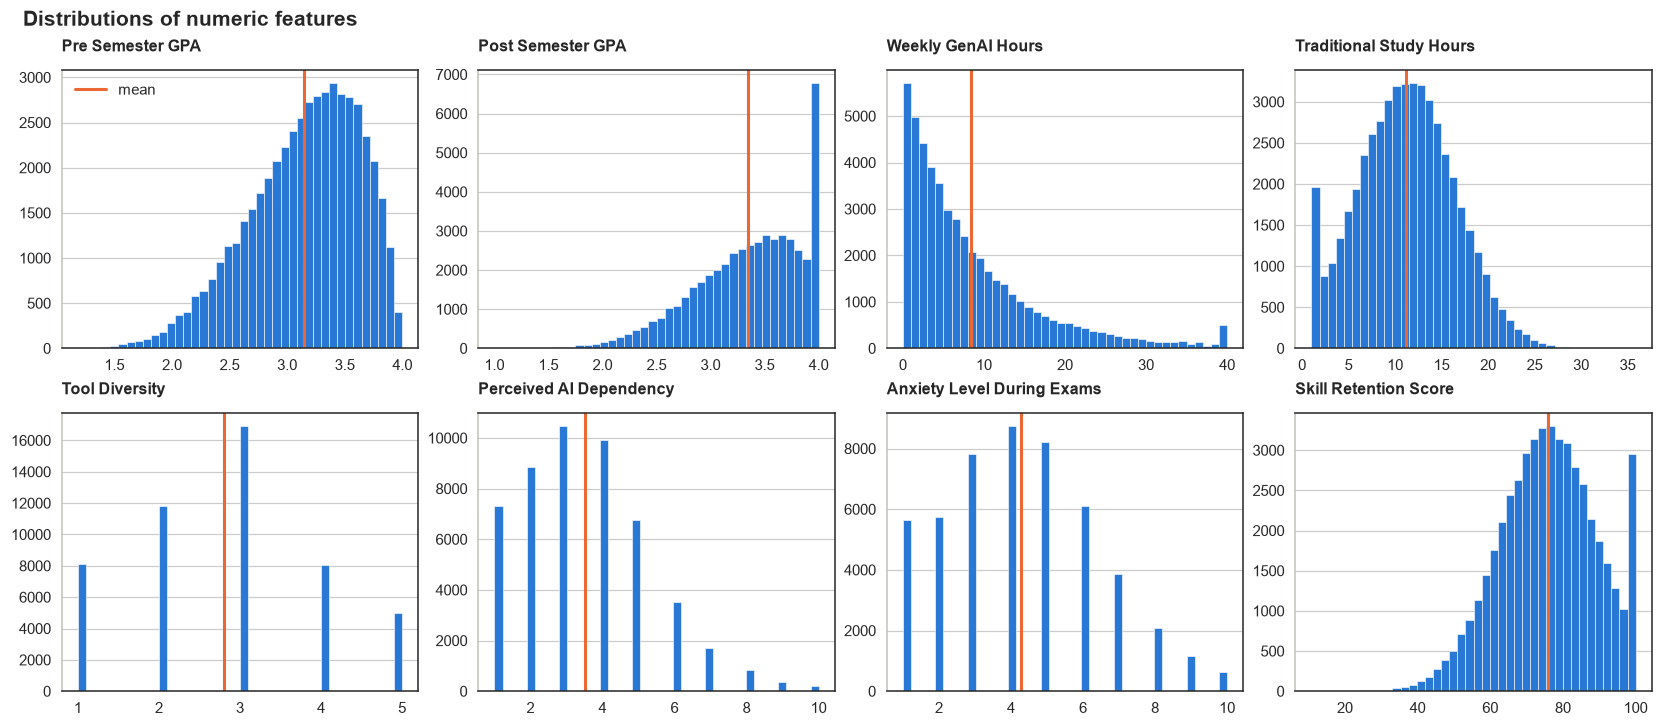

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), constrained_layout=True)
for ax, col in zip(axes.ravel(), num_cols):
    ax.hist(df_raw[col], bins=40, color=PALETTE["blue"], edgecolor=SURFACE, linewidth=0.4)
    ax.axvline(df_raw[col].mean(), color=PALETTE["orange"], lw=2, label="mean")
    ax.set_title(col.replace("_", " "), fontsize=10.5)
    style_axis(ax)
axes[0, 0].legend(loc="upper left")
fig.suptitle("Distributions of numeric features", fontsize=14, fontweight="bold", x=0.01, ha="left")
plt.show()

**Reading the grid.** The two GPA fields show a ceiling at 4.0 typical of
grade data. `Weekly_GenAI_Hours` and `Traditional_Study_Hours` are right-skewed:
most students use GenAI modestly, with a long tail of heavy users - the tail
that the dose-response analysis in later notebooks focuses on.

## 5. Categorical composition

Counts for every categorical field, so we know the balance of the groups we will
later compare.

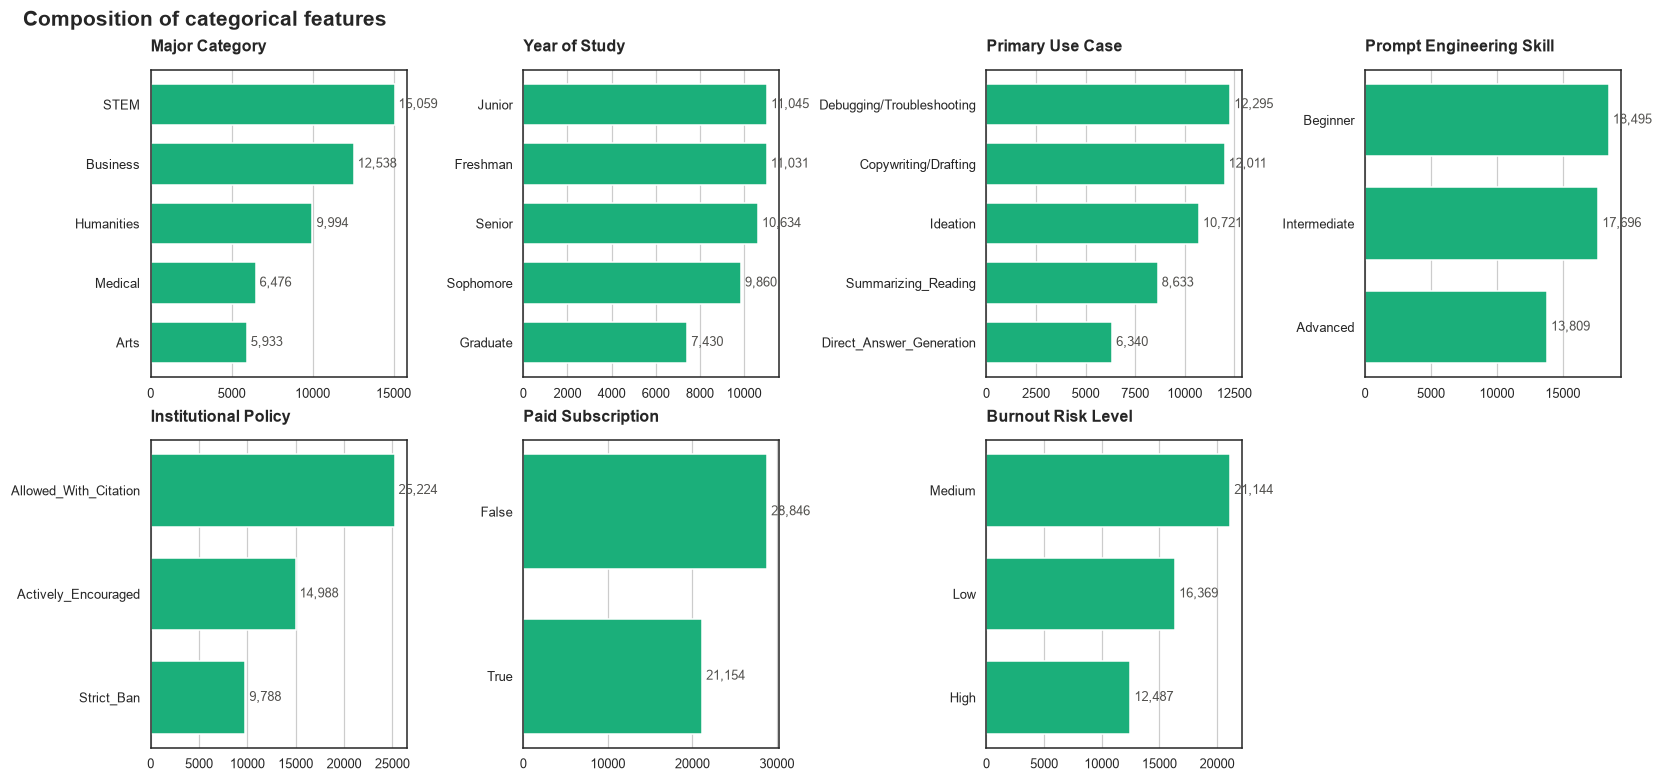

In [8]:
cat_cols = ["Major_Category", "Year_of_Study", "Primary_Use_Case",
            "Prompt_Engineering_Skill", "Institutional_Policy",
            "Paid_Subscription", "Burnout_Risk_Level"]
fig, axes = plt.subplots(2, 4, figsize=(15, 7), constrained_layout=True)
for ax, col in zip(axes.ravel(), cat_cols):
    vc = df_raw[col].astype(str).value_counts().sort_values()
    ax.barh(vc.index, vc.values, color=PALETTE["aqua"], height=0.7)
    for y, v in enumerate(vc.values):
        ax.text(v, y, f" {v:,}", va="center", fontsize=8.5, color=INK_SOFT)
    ax.set_title(col.replace("_", " "), fontsize=10.5)
    ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
    ax.tick_params(labelsize=8.5)
axes[-1, -1].axis("off")
fig.suptitle("Composition of categorical features", fontsize=14, fontweight="bold", x=0.01, ha="left")
plt.show()

**Reading the panels.** The cohort is dominated by STEM and Business
students, spread fairly evenly across years of study, and most commonly operates
under an *allowed-with-citation* policy. Burnout risk is modal at *Medium*. No
group is so small that later comparisons will be underpowered.

## 6. Plausibility checks

Every field has a defined admissible range (see the variable dictionary in the
README). We assert those ranges explicitly; a violation would signal a data
error rather than a finding.

In [9]:
checks = {
    "Pre_Semester_GPA in [0,4]":  df_raw["Pre_Semester_GPA"].between(0, 4).all(),
    "Post_Semester_GPA in [0,4]": df_raw["Post_Semester_GPA"].between(0, 4).all(),
    "Weekly_GenAI_Hours >= 0":    (df_raw["Weekly_GenAI_Hours"] >= 0).all(),
    "Traditional_Study_Hours >= 0": (df_raw["Traditional_Study_Hours"] >= 0).all(),
    "Tool_Diversity in [1,5]":    df_raw["Tool_Diversity"].between(1, 5).all(),
    "Dependency in [1,10]":       df_raw["Perceived_AI_Dependency"].between(1, 10).all(),
    "Anxiety in [1,10]":          df_raw["Anxiety_Level_During_Exams"].between(1, 10).all(),
    "Skill_Retention in [0,100]": df_raw["Skill_Retention_Score"].between(0, 100).all(),
}
for name, ok in checks.items():
    print(f"[{'PASS' if ok else 'FAIL'}] {name}")
assert all(checks.values()), "A plausibility check failed"

[PASS] Pre_Semester_GPA in [0,4]
[PASS] Post_Semester_GPA in [0,4]
[PASS] Weekly_GenAI_Hours >= 0
[PASS] Traditional_Study_Hours >= 0
[PASS] Tool_Diversity in [1,5]
[PASS] Dependency in [1,10]
[PASS] Anxiety in [1,10]
[PASS] Skill_Retention in [0,100]


## 7. Outlier characterisation

For the two long-tailed usage variables we quantify the tail with the IQR rule.
We *characterise* outliers rather than removing them: heavy GenAI use is not an
error, it is precisely the behaviour of interest.

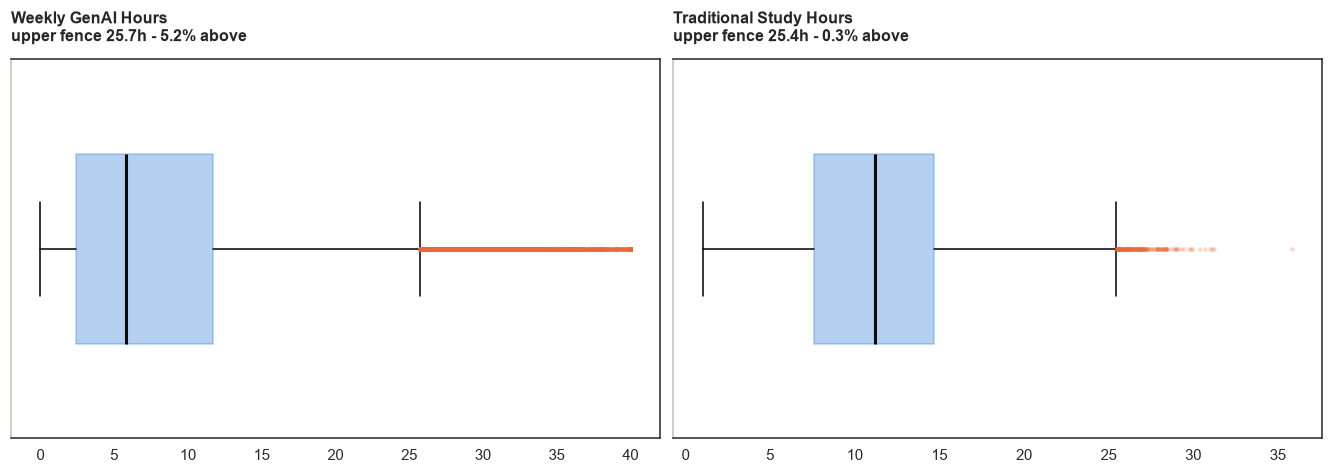

In [10]:
def iqr_fence(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    hi = q3 + 1.5 * iqr
    return hi, float((s > hi).mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
for ax, col in zip(axes, ["Weekly_GenAI_Hours", "Traditional_Study_Hours"]):
    hi, pct = iqr_fence(df_raw[col])
    bp = ax.boxplot(df_raw[col], vert=False, widths=0.5, patch_artist=True,
                    flierprops=dict(marker="o", markersize=3, alpha=0.25,
                                    markerfacecolor=PALETTE["orange"], markeredgecolor="none"))
    bp["boxes"][0].set(facecolor=PALETTE["blue"], alpha=0.35, edgecolor=PALETTE["blue"])
    for med in bp["medians"]: med.set(color=INK, linewidth=2)
    ax.set_title(f"{col.replace('_',' ')}\nupper fence {hi:.1f}h - {pct:.1f}% above", fontsize=10.5)
    ax.set_yticks([]); style_axis(ax)
plt.show()

## 8. Feature engineering

We derive the analysis variables used throughout the study. Each is motivated by
a research question in the README.

- **`GPA_Delta`** - the within-student change in GPA across the semester; the
  primary continuous outcome (RQ4).
- **`GenAI_Intensity_Band`** - ordered usage bands for the dose-response
  analysis (RQ1).
- **`Study_AI_Ratio`** - study hours per hour of GenAI use; a substitution proxy
  (RQ4).
- **`Offloading_Use`** - flags cognitive-offloading use (direct answer
  generation) against analytic/generative use (RQ2).
- Ordinal encodings for `Year_of_Study` and `Prompt_Engineering_Skill` for use
  in correlations and models.

In [11]:
df = df_raw.copy()

# Primary outcome: within-student GPA change
df["GPA_Delta"] = (df["Post_Semester_GPA"] - df["Pre_Semester_GPA"]).round(3)

# Dose-response bands (ordered categorical)
band_edges = [-0.01, 2, 8, 15, df["Weekly_GenAI_Hours"].max()]
band_labels = ["None/Minimal (0-2h)", "Light (2-8h)", "Moderate (8-15h)", "Heavy (15h+)"]
df["GenAI_Intensity_Band"] = pd.Categorical(
    pd.cut(df["Weekly_GenAI_Hours"], bins=band_edges, labels=band_labels),
    categories=band_labels, ordered=True)

# Substitution proxy (guard against divide-by-zero)
df["Study_AI_Ratio"] = (df["Traditional_Study_Hours"] /
                        df["Weekly_GenAI_Hours"].clip(lower=0.5)).round(2)

# Cognitive-offloading flag
df["Offloading_Use"] = (df["Primary_Use_Case"] == "Direct_Answer_Generation").astype(int)

# Ordinal encodings
year_order = ["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]
skill_order = ["Beginner", "Intermediate", "Advanced"]
df["Year_Ordinal"] = df["Year_of_Study"].map({v: i for i, v in enumerate(year_order)})
df["PromptSkill_Ordinal"] = df["Prompt_Engineering_Skill"].map({v: i for i, v in enumerate(skill_order)})

print("Engineered columns added:",
      ["GPA_Delta", "GenAI_Intensity_Band", "Study_AI_Ratio",
       "Offloading_Use", "Year_Ordinal", "PromptSkill_Ordinal"])
df[["GPA_Delta", "GenAI_Intensity_Band", "Study_AI_Ratio", "Offloading_Use"]].describe(include="all").T

Engineered columns added: ['GPA_Delta', 'GenAI_Intensity_Band', 'Study_AI_Ratio', 'Offloading_Use', 'Year_Ordinal', 'PromptSkill_Ordinal']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GPA_Delta,50000.0,NaN,NaN,NaN,0.203197,0.187192,-0.924,0.087,0.204,0.325,1.008
GenAI_Intensity_Band,50000,4,Light (2-8h),20022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Study_AI_Ratio,50000.0,NaN,NaN,NaN,4.631269,7.15639,0.02,0.78,1.84,4.7625,71.72
Offloading_Use,50000.0,NaN,NaN,NaN,0.1268,0.332752,0.0,0.0,0.0,0.0,1.0


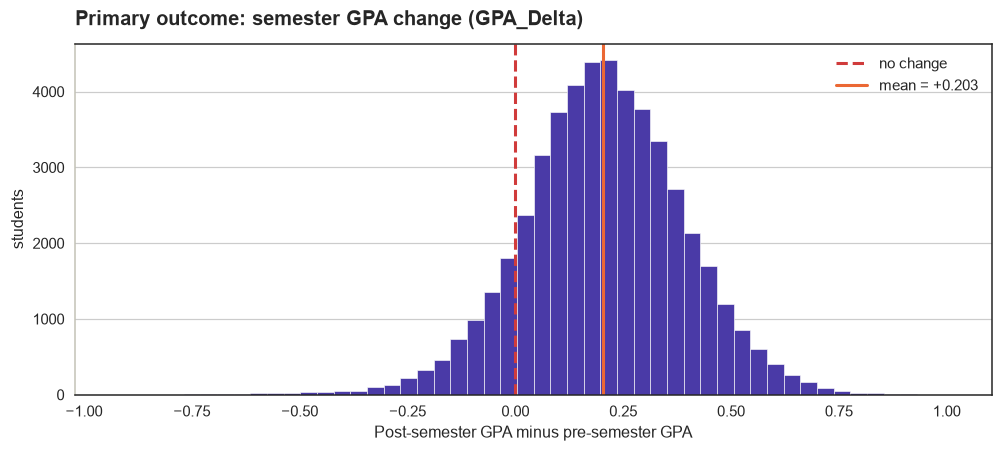

87.5% of students improved their GPA over the semester.


In [12]:
# Sanity view of the primary outcome
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.hist(df["GPA_Delta"], bins=50, color=PALETTE["violet"], edgecolor=SURFACE, linewidth=0.4)
ax.axvline(0, color=CRITICAL, lw=2, ls="--", label="no change")
ax.axvline(df["GPA_Delta"].mean(), color=PALETTE["orange"], lw=2, label=f"mean = {df['GPA_Delta'].mean():+.3f}")
ax.set_title("Primary outcome: semester GPA change (GPA_Delta)")
ax.set_xlabel("Post-semester GPA minus pre-semester GPA"); ax.set_ylabel("students")
ax.legend(); style_axis(ax)
plt.show()
print(f"{(df['GPA_Delta'] > 0).mean()*100:.1f}% of students improved their GPA over the semester.")

**Reading it.** The average student gains roughly +0.20 GPA points across
the semester and a clear majority improve. The task of the study is not to
explain this overall rise but to explain *why some students gain much more than
others* - and whether GenAI usage patterns are part of that explanation.

## 9. Persist the clean analysis table

The engineered table is written to `data/processed/students_clean.csv`. Notebooks
02-04 load this file rather than repeating the cleaning, so all analyses share an
identical, versioned starting point.

In [13]:
df.to_csv(PROC_CSV, index=False)
print(f"Wrote {df.shape[0]:,} rows x {df.shape[1]} columns to:")
print(f"  {PROC_CSV.relative_to(ROOT)}")

Wrote 50,000 rows x 22 columns to:
  data/processed/students_clean.csv


## Summary

- The dataset is complete (no missing values), has one row per student, and all
  fields fall within their defined ranges - it is trustworthy.
- Usage variables are right-skewed with genuine heavy-use tails that we retain.
- We engineered the study's key variables, above all `GPA_Delta`, the
  within-student outcome that lets later notebooks ask *who improves and why*.
- A single clean table is now persisted for the rest of the study.

**Next:** Notebook 02 explores this table visually - distributions by group, the
dose-response curve, use-case comparisons, and the correlation structure.